# 6CS012 – Part III: NLP Language Task
## Sentiment Analysis of IMDb Movie Reviews Using RNN, LSTM, and Word2Vec Embeddings
**Student Name:** Binaya Bohara(2418248)

**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Institution:** Herald College, Kathmandu / University of Wolverhampton  
**Team:** Rajiv Khattri (2408207) | Binaya Bohara (2418248) | Unik Ghalan (2409043)

---
### Notebook Structure
| Cell Block | Description |
|---|---|
| **0** | Environment setup & GPU check |
| **1** | Dataset loading from ZIP / Google Drive |
| **2** | EDA & visualisation |
| **3** | Text preprocessing pipeline |
| **4** | Tokenisation & sequence padding |
| **5** | Model 1 – Simple RNN + trainable Embedding |
| **6** | Model 2 – LSTM + trainable Embedding |
| **7** | Model 3 – LSTM + pre-trained GloVe (Word2Vec-style) |
| **8** | Comparative evaluation & plots |
| **9** | Error analysis |
| **10** | Gradio GUI for real-time prediction |


---
## Block 0 – Environment Setup & GPU Check

In [1]:
# 0.1  Install / upgrade required packages
# Run once per Colab session; restart runtime if prompted after gensim install.
!pip install -q contractions wordcloud gradio
!pip install -q numpy==1.23.5          # gensim compatibility requirement (per brief Appendix)
!pip install -q gensim

# NLTK corpora
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 86.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.9 MB/s eta 0:00:00


True

In [2]:
# 0.2  Standard imports
import os, re, time, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# NLP
import contractions
from nltk.corpus         import stopwords
from nltk.stem           import WordNetLemmatizer
from wordcloud           import WordCloud
from collections         import Counter

# Keras / TF
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import (Embedding, SimpleRNN, LSTM,
                                         Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

# Sklearn
from sklearn.metrics import (accuracy_score, confusion_matrix,
                               classification_report, ConfusionMatrixDisplay)

# 0.3  GPU / hardware check
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs detected:', gpus if gpus else 'None — consider enabling GPU in Runtime > Change runtime type')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Block 1 – Dataset Loading

> **Two loading options provided.**  
> - **Option A** (recommended): mount your Google Drive and read CSVs directly.  
> - **Option B**: upload the ZIP locally inside Colab using `files.upload()`.

The dataset ZIP (`5__Movie_Review_Dataset-*.zip`) contains:
```
5. Movie Review Dataset/
    train_movie_review.csv   – 35,000 reviews
    val_movie_review.csv     –  5,000 reviews
    test_movie_review.csv    – 10,000 reviews
```
Each CSV has three columns: *index*, *review*, *sentiment* (0 = negative, 1 = positive).

In [4]:
import os
import zipfile, io


# Using the provided zip file path directly instead of uploading
zip_file_path = '/content/5. Movie Review Dataset.zip'
extracted_dir = '/content/dataset/'
os.makedirs(extracted_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as z:
    z.extractall(extracted_dir)

# Assuming the zip file extracts into a folder named '5. Movie Review Dataset'
DATA_DIR = os.path.join(extracted_dir, '5. Movie Review Dataset/')

# 1.4  Load CSVs
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_movie_review.csv'), index_col=0)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_movie_review.csv'),   index_col=0)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_movie_review.csv'),  index_col=0)

# Drop any rows with missing labels (unlabeled data per dataset description)
df_train.dropna(subset=['sentiment'], inplace=True)
df_val.dropna(  subset=['sentiment'], inplace=True)
df_test.dropna( subset=['sentiment'], inplace=True)

# Ensure correct types
for df in [df_train, df_val, df_test]:
    df['sentiment'] = df['sentiment'].astype(int)
    df['review']    = df['review'].astype(str)

print(f'Train: {df_train.shape}  |  Val: {df_val.shape}  |  Test: {df_test.shape}')
df_train.head(2)

Train: (35000, 2)  |  Val: (5000, 2)  |  Test: (10000, 2)


,review,sentiment
3774,"Having avoided seeing the movie in the cinema,...",0
48396,With this movie I was really hoping that the i...,0


---
## Block 2 – Exploratory Data Analysis & Visualisation

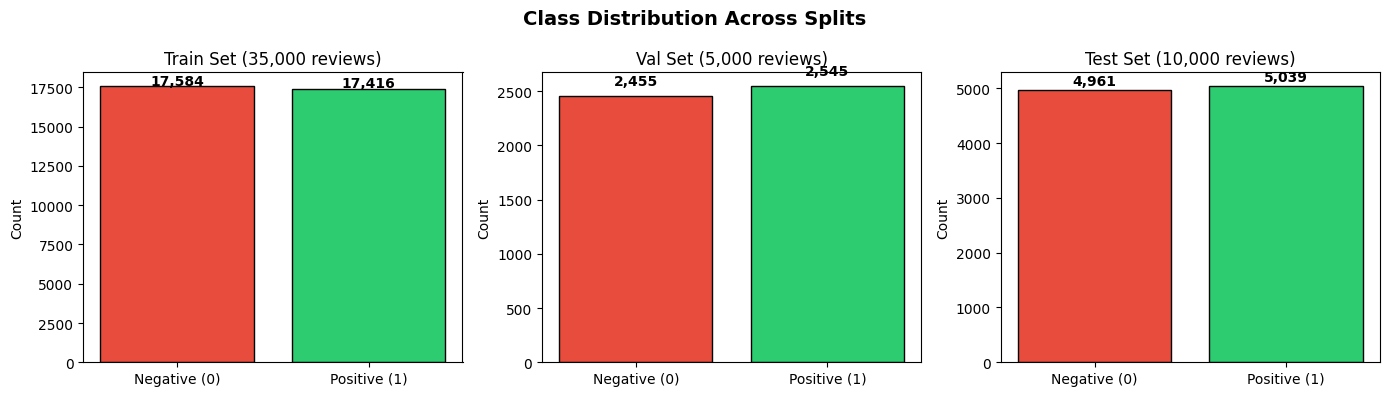

Class balance is near-perfect — standard accuracy is a valid primary metric.


In [5]:
# 2.1  Class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ['Negative (0)', 'Positive (1)']
for ax, (df, name) in zip(axes, [(df_train,'Train'),(df_val,'Val'),(df_test,'Test')]):
    counts = df['sentiment'].value_counts().sort_index()
    ax.bar(labels, counts.values, color=['#e74c3c','#2ecc71'], edgecolor='black')
    ax.set_title(f'{name} Set ({len(df):,} reviews)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class balance is near-perfect — standard accuracy is a valid primary metric.')

=== Word Count Statistics (Training Set) ===
count    35000.0
mean       230.7
std        171.0
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: word_count, dtype: float64

75th percentile: 280 words  |  90th percentile: 449 words
→ We will use MAX_LEN = 280 (75th percentile) for sequence padding.


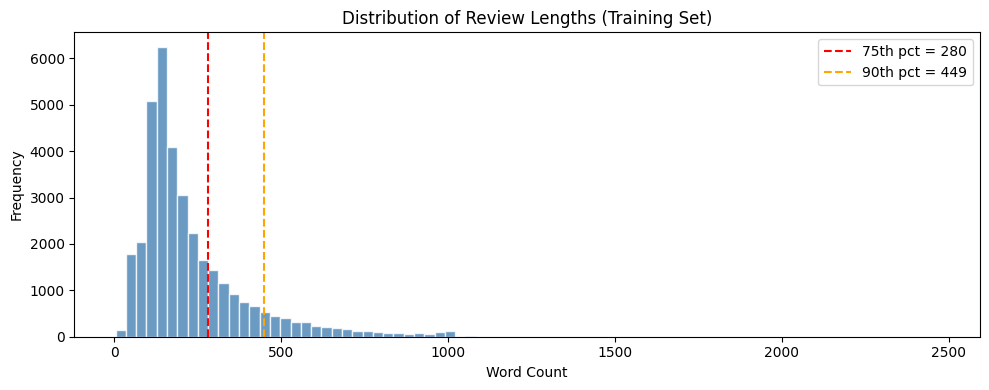

In [6]:
# 2.2  Review length statistics
df_train['word_count'] = df_train['review'].apply(lambda x: len(x.split()))
df_train['char_count'] = df_train['review'].apply(len)

print('=== Word Count Statistics (Training Set) ===')
print(df_train['word_count'].describe().round(1))

p75 = int(np.percentile(df_train['word_count'], 75))
p90 = int(np.percentile(df_train['word_count'], 90))
print(f'\n75th percentile: {p75} words  |  90th percentile: {p90} words')
print(f'→ We will use MAX_LEN = {p75} (75th percentile) for sequence padding.')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_train['word_count'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(p75, color='red',    linestyle='--', label=f'75th pct = {p75}')
ax.axvline(p90, color='orange', linestyle='--', label=f'90th pct = {p90}')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Review Lengths (Training Set)')
ax.legend()
plt.tight_layout()
plt.savefig('review_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 3 – Text Preprocessing Pipeline

Steps (as specified in the brief §4.5.1 and proposal §4.2):
1. Remove HTML tags (`<br />`, `&amp;` etc.)
2. Expand contractions (`don't` → `do not`)
3. Lowercase
4. Remove URLs, mentions, hashtags, numbers, special characters
5. Remove stopwords
6. Lemmatize

In [7]:
# 3.1  Build preprocessing function
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    """Full preprocessing pipeline for a single review string."""
    # Step 1 – Remove HTML artefacts
    text = re.sub(r'<[^>]+>', ' ', text)          # strip tags
    text = re.sub(r'&[a-z]+;', ' ', text)         # strip HTML entities
    # Step 2 – Expand contractions BEFORE lowercasing (library is case-sensitive)
    text = contractions.fix(text)
    # Step 3 – Lowercase
    text = text.lower()
    # Step 4 – Remove URLs, mentions, hashtags, numbers, special characters
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # URLs
    text = re.sub(r'@\w+',             ' ', text)  # mentions
    text = re.sub(r'#\w+',             ' ', text)  # hashtags
    text = re.sub(r'\d+',              ' ', text)  # numbers
    text = re.sub(r'[^a-z\s]',         ' ', text)  # special characters
    # Step 5 & 6 – Tokenise, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

# Quick sanity check
raw_example = df_train['review'].iloc[0]
print('RAW (first 200 chars):  ', raw_example[:200])
print('CLEAN (first 200 chars):', preprocess_text(raw_example)[:200])

RAW (first 200 chars):   Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
CLEAN (first 200 chars): avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race al


In [8]:
# 3.2  Apply preprocessing to all splits
# ~35 k reviews on GPU Colab should take 2-3 minutes
print('Preprocessing training set...')
t0 = time.time()
df_train['clean'] = df_train['review'].apply(preprocess_text)
print(f'  Done in {time.time()-t0:.1f}s')

print('Preprocessing validation set...')
df_val['clean']   = df_val['review'].apply(preprocess_text)

print('Preprocessing test set...')
df_test['clean']  = df_test['review'].apply(preprocess_text)
print('All sets preprocessed.')

Preprocessing training set...
  Done in 23.4s
Preprocessing validation set...
Preprocessing test set...
All sets preprocessed.


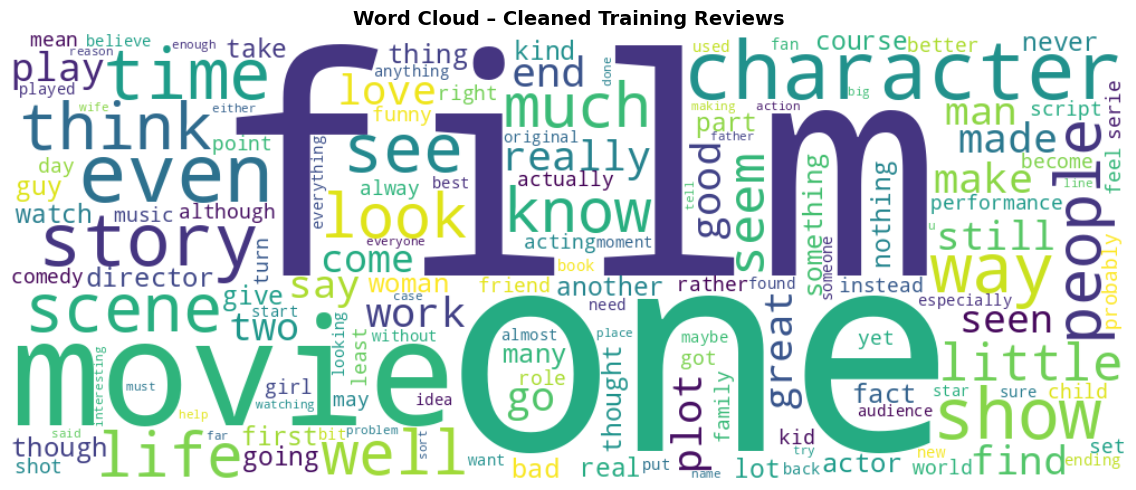

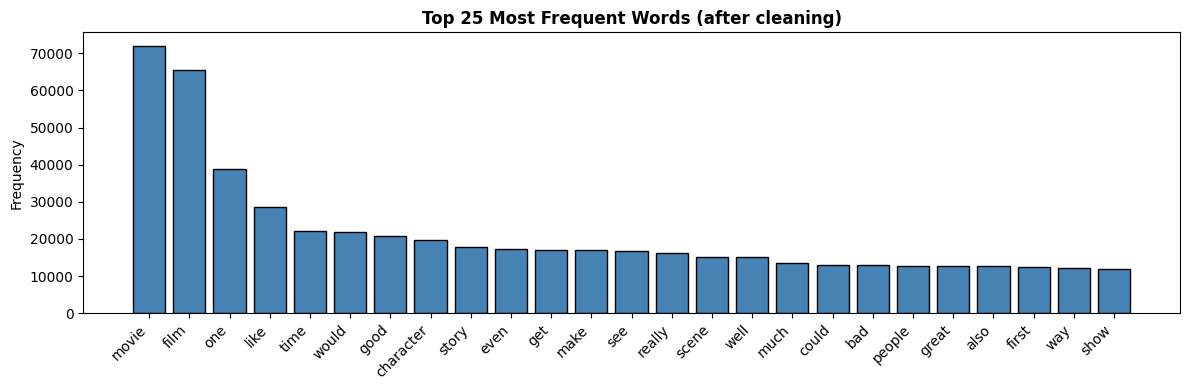

In [9]:
# 3.3  Visualise cleaned text
# Word cloud – all training reviews combined
all_clean_text = ' '.join(df_train['clean'].tolist())

wc = WordCloud(width=1000, height=400, background_color='white',
               colormap='viridis', max_words=150).generate(all_clean_text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – Cleaned Training Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# Top-25 most frequent words bar chart
word_freq = Counter(all_clean_text.split())
top25 = word_freq.most_common(25)
words, counts = zip(*top25)

plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Top 25 Most Frequent Words (after cleaning)', fontweight='bold')
plt.tight_layout()
plt.savefig('top25_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 4 – Tokenisation & Sequence Padding

- **Vocabulary size**: top 20,000 most frequent tokens (covers ~95 % of corpus)  
- **Max sequence length**: 75th percentile ≈ **280 words** (as decided in proposal §4.2, confirmed from EDA above)  
- Padding/truncation: `post` padding, `pre` truncation (standard for RNN/LSTM)


In [10]:
# 4.1  Keras Tokenizer
VOCAB_SIZE = 20_000
MAX_LEN    = int(np.percentile(df_train['clean'].apply(lambda x: len(x.split())), 75))
print(f'Vocabulary size : {VOCAB_SIZE:,}')
print(f'Max sequence len: {MAX_LEN} tokens (75th percentile)')

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df_train['clean'])      # fit ONLY on training data

word_index  = tokenizer.word_index
print(f'Unique tokens in training corpus: {len(word_index):,}')
print(f'Tokens kept (vocab_size): {VOCAB_SIZE:,}')

Vocabulary size : 20,000
Max sequence len: 143 tokens (75th percentile)
Unique tokens in training corpus: 77,113
Tokens kept (vocab_size): 20,000


In [11]:
# 4.2  Encode and pad sequences
def encode_pad(texts, tokenizer, maxlen):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='pre')

X_train = encode_pad(df_train['clean'], tokenizer, MAX_LEN)
X_val   = encode_pad(df_val['clean'],   tokenizer, MAX_LEN)
X_test  = encode_pad(df_test['clean'],  tokenizer, MAX_LEN)

y_train = df_train['sentiment'].values
y_val   = df_val['sentiment'].values
y_test  = df_test['sentiment'].values

print('X_train shape:', X_train.shape)
print('X_val   shape:', X_val.shape)
print('X_test  shape:', X_test.shape)

X_train shape: (35000, 143)
X_val   shape: (5000, 143)
X_test  shape: (10000, 143)


---
## Block 5 – Model 1: Simple RNN + Trainable Embedding

> **Purpose**: Establish a recurrent baseline. SimpleRNN cannot retain long-range context (vanishing gradient), so we expect this to underperform LSTM.

In [12]:
# 5.1  Hyper-parameters (shared across models)
EMBED_DIM  = 64      # embedding dimension for trainable layers
BATCH_SIZE = 128
EPOCHS     = 15      # EarlyStopping will cut short if needed
LR         = 1e-3

# 5.2  Build Model 1──
model1 = Sequential(name='Model1_SimpleRNN', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding_m1'),
    SimpleRNN(64, return_sequences=False, name='simple_rnn'),
    Dropout(0.5, name='dropout_m1'),
    Dense(1, activation='sigmoid', name='output_m1')
])

model1.compile(optimizer=Adam(learning_rate=LR),
               loss='binary_crossentropy',
               metrics=['accuracy'])
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_m1 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_m1 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_m1 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 5.3  Callbacks
def make_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=3,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                          min_lr=1e-6, verbose=1)
    ]

# 5.4  Train Model 1
print('Training Model 1 – Simple RNN ...')
t0 = time.time()
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks('model1'),
    verbose=1
)
m1_train_time = time.time() - t0
print(f'Training time: {m1_train_time:.1f}s')

Training Model 1 – Simple RNN ...
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5075 - loss: 0.6967 - val_accuracy: 0.5244 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5873 - loss: 0.6601 - val_accuracy: 0.5478 - val_loss: 0.6793 - learning_rate: 0.0010
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6485 - loss: 0.5970 - val_accuracy: 0.5642 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6566 - loss: 0.5726 - val_accuracy: 0.5508 - val_loss: 0.7050 - learning_rate: 0.0010
Epoch 5/15
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6702 - loss: 0.5685
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6671 - loss: 0.5665 - val_accuracy: 0.5426 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/

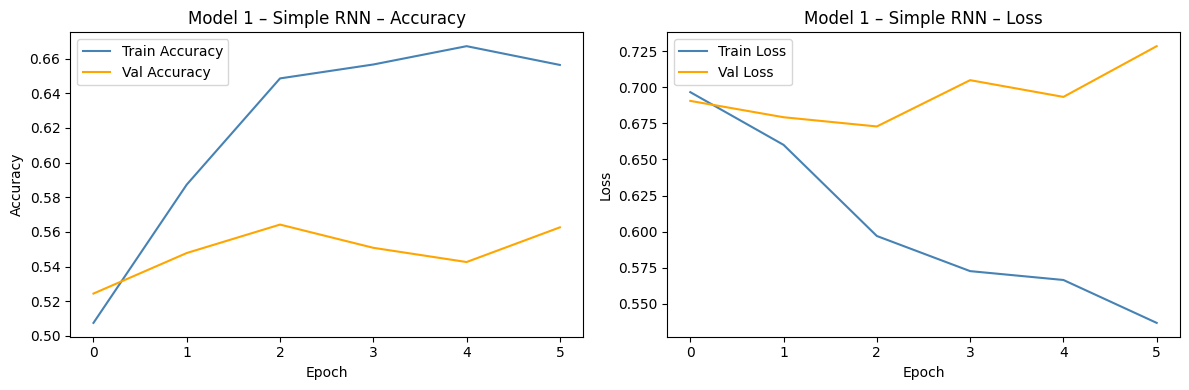

In [14]:
# 5.5  Plot training curves
def plot_history(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    ax1.set_title(f'{title} – Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue')
    ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
    ax2.set_title(f'{title} – Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, 'Model 1 – Simple RNN', 'model1_curves')


=== Model 1 (Simple RNN) – Test Set Evaluation ===
Accuracy: 0.5659  (56.59%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.46      0.51      4961
    Positive       0.56      0.67      0.61      5039

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.56     10000
weighted avg       0.57      0.57      0.56     10000



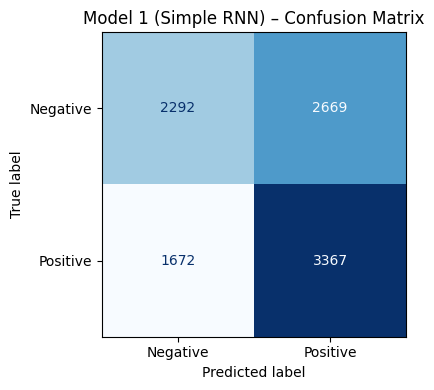

In [15]:
# 5.6  Evaluate Model 1 on test set
def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test, batch_size=256, verbose=0)
    y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    print(f'\n=== {model_name} – Test Set Evaluation ===')
    print(f'Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Negative','Positive']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Negative','Positive'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_cm.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred, y_pred_prob

acc1, pred1, prob1 = evaluate_model(model1, X_test, y_test, 'Model 1 (Simple RNN)')

---
## Block 6 – Model 2: LSTM + Trainable Embedding

> **Purpose**: LSTMs use gating mechanisms (forget, input, output gates) to handle long-range dependencies, addressing the vanishing gradient weakness of SimpleRNN.

In [16]:
# 6.1  Build Model 2
model2 = Sequential(name='Model2_LSTM', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding_m2'),
    LSTM(64, return_sequences=False, name='lstm_m2'),
    Dropout(0.5, name='dropout_m2'),
    Dense(1, activation='sigmoid', name='output_m2')
])

model2.compile(optimizer=Adam(learning_rate=LR),
               loss='binary_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_m2 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_m2 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_m2 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_m2 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Model 2 – LSTM ...
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5801 - loss: 0.6634 - val_accuracy: 0.7336 - val_loss: 0.5645 - learning_rate: 0.0010
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7472 - loss: 0.5679 - val_accuracy: 0.6650 - val_loss: 0.6309 - learning_rate: 0.0010
Epoch 3/15
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6470 - loss: 0.6398
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6193 - loss: 0.6531 - val_accuracy: 0.5740 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6571 - loss: 0.6192 - val_accuracy: 0.6684 - val_loss: 0.5791 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Training time: 23.4s


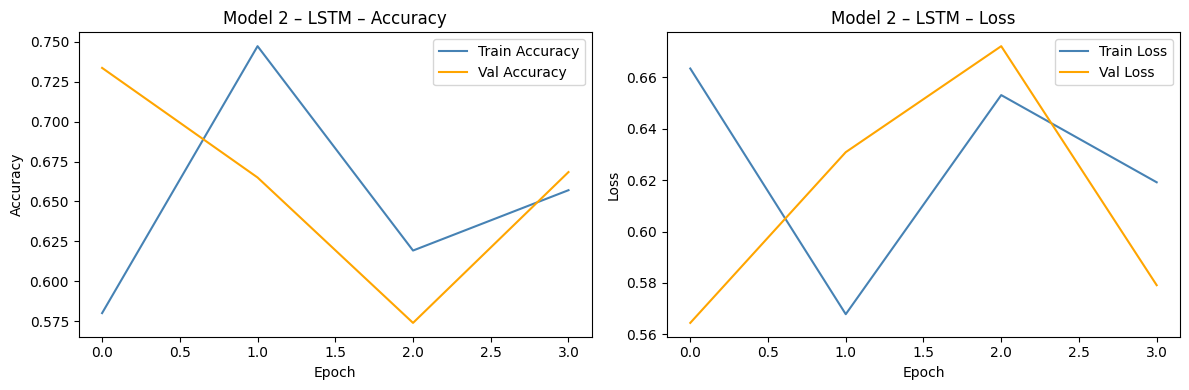


=== Model 2 (LSTM) – Test Set Evaluation ===
Accuracy: 0.7237  (72.37%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.57      0.67      4961
    Positive       0.67      0.87      0.76      5039

    accuracy                           0.72     10000
   macro avg       0.75      0.72      0.72     10000
weighted avg       0.75      0.72      0.72     10000



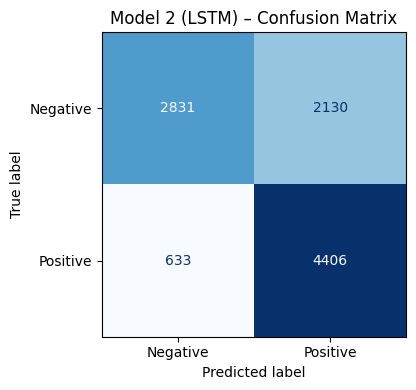

In [17]:
# 6.2  Train Model 2
print('Training Model 2 – LSTM ...')
t0 = time.time()
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks('model2'),
    verbose=1
)
m2_train_time = time.time() - t0
print(f'Training time: {m2_train_time:.1f}s')

plot_history(history2, 'Model 2 – LSTM', 'model2_curves')
acc2, pred2, prob2 = evaluate_model(model2, X_test, y_test, 'Model 2 (LSTM)')

---
## Block 7 – Model 3: LSTM + Pre-trained GloVe (Word2Vec-style) Embeddings

> **Embedding**: `glove-twitter-100` (100-dim) via Gensim API.  
> Twitter text shares informal writing characteristics with IMDb reviews.  
> OOV tokens receive zero vectors. Embedding layer is **frozen** (`trainable=False`).

In [18]:
# 7.1  Load pre-trained GloVe via Gensim
# NOTE: This download (~200 MB) may take 2-5 minutes on Colab.
import gensim.downloader as gensim_api

GLOVE_MODEL  = 'glove-twitter-100'   # 100-dimensional GloVe on Twitter corpus
GLOVE_DIM    = 100

print(f'Downloading {GLOVE_MODEL} embeddings (first-time ~200 MB)...')
t0 = time.time()
glove_model = gensim_api.load(GLOVE_MODEL)
print(f'Loaded in {time.time()-t0:.1f}s  |  Vocab size: {len(glove_model):,}')

[==================================================] 100.0% 387.1/387.1MB downloaded
Loaded in 209.8s  |  Vocab size: 1,193,514


In [19]:
# 7.2  Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
oov_count = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
    else:
        oov_count += 1   # zero vector (already zeroed by np.zeros)

coverage = 1 - oov_count / min(len(word_index), VOCAB_SIZE)
print(f'Embedding matrix shape : {embedding_matrix.shape}')
print(f'Vocabulary coverage    : {coverage:.1%}  ({oov_count:,} OOV tokens → zero vectors)')

Embedding matrix shape : (20000, 100)
Vocabulary coverage    : 96.4%  (711 OOV tokens → zero vectors)


In [20]:
# 7.3  Build Model 3
model3 = Sequential(name='Model3_LSTM_GloVe', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=GLOVE_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False,           # freeze pre-trained vectors
              name='glove_embedding'),
    LSTM(64, return_sequences=False, name='lstm_m3'),
    Dropout(0.5, name='dropout_m3'),
    Dense(1, activation='sigmoid', name='output_m3')
])

model3.compile(optimizer=Adam(learning_rate=LR),
               loss='binary_crossentropy',
               metrics=['accuracy'])
model3.summary()
print(f'\nNon-trainable params (frozen embedding): {embedding_matrix.size:,}')

Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_m3 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_m3 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_m3 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)


Non-trainable params (frozen embedding): 2,000,000


Training Model 3 – LSTM + GloVe ...
Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6690 - loss: 0.6101 - val_accuracy: 0.5076 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5629 - loss: 0.6739 - val_accuracy: 0.5590 - val_loss: 0.7271 - learning_rate: 0.0010
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6870 - loss: 0.6101 - val_accuracy: 0.7164 - val_loss: 0.5721 - learning_rate: 0.0010
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7564 - loss: 0.5453 - val_accuracy: 0.7612 - val_loss: 0.5239 - learning_rate: 0.0010
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6186 - loss: 0.6365 - val_accuracy: 0.6028 - val_loss: 0.6518 - learning_rate: 0.0010
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6991 - loss: 0.5872
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms

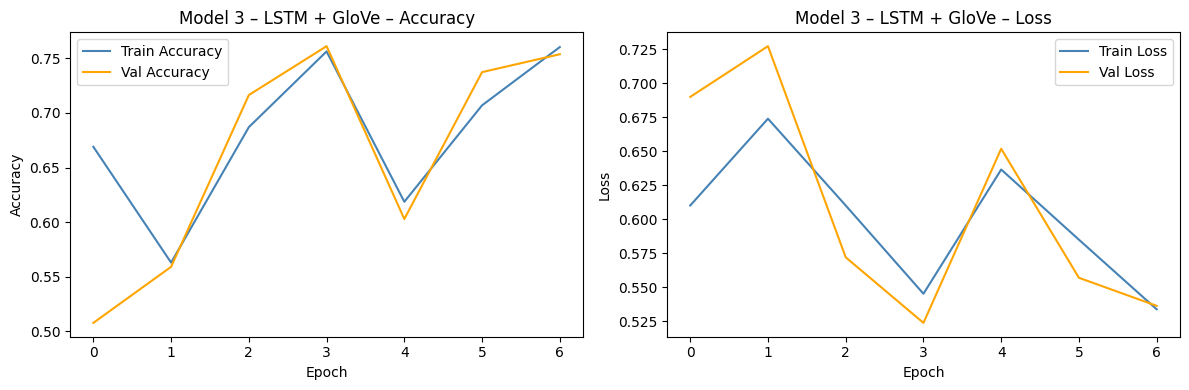


=== Model 3 (LSTM+GloVe) – Test Set Evaluation ===
Accuracy: 0.7536  (75.36%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.61      0.71      4961
    Positive       0.70      0.89      0.79      5039

    accuracy                           0.75     10000
   macro avg       0.77      0.75      0.75     10000
weighted avg       0.77      0.75      0.75     10000



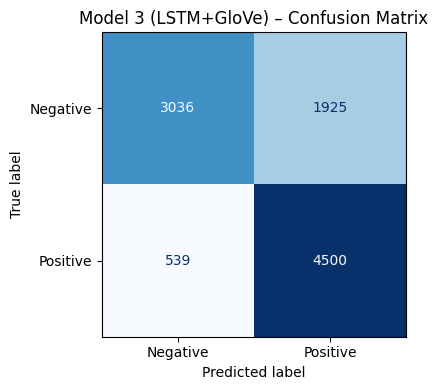

In [21]:
# 7.4  Train Model 3
print('Training Model 3 – LSTM + GloVe ...')
t0 = time.time()
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks('model3'),
    verbose=1
)
m3_train_time = time.time() - t0
print(f'Training time: {m3_train_time:.1f}s')

plot_history(history3, 'Model 3 – LSTM + GloVe', 'model3_curves')
acc3, pred3, prob3 = evaluate_model(model3, X_test, y_test, 'Model 3 (LSTM+GloVe)')

---
## Block 8 – Comparative Evaluation & Plots

In [22]:
# 8.1  Summary comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics_row(name, y_true, y_pred, train_time):
    return {
        'Model'         : name,
        'Accuracy'      : round(accuracy_score(y_true, y_pred), 4),
        'Precision'     : round(precision_score(y_true, y_pred), 4),
        'Recall'        : round(recall_score(y_true, y_pred), 4),
        'F1-Score'      : round(f1_score(y_true, y_pred), 4),
        'Train Time (s)': round(train_time, 1),
    }

results = pd.DataFrame([
    metrics_row('Model 1 – Simple RNN',   y_test, pred1, m1_train_time),
    metrics_row('Model 2 – LSTM',         y_test, pred2, m2_train_time),
    metrics_row('Model 3 – LSTM + GloVe', y_test, pred3, m3_train_time),
])
print(results.to_string(index=False))

                 Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)
  Model 1 – Simple RNN    0.5659     0.5578  0.6682    0.6080            31.6
        Model 2 – LSTM    0.7237     0.6741  0.8744    0.7613            23.4
Model 3 – LSTM + GloVe    0.7536     0.7004  0.8930    0.7851            23.5


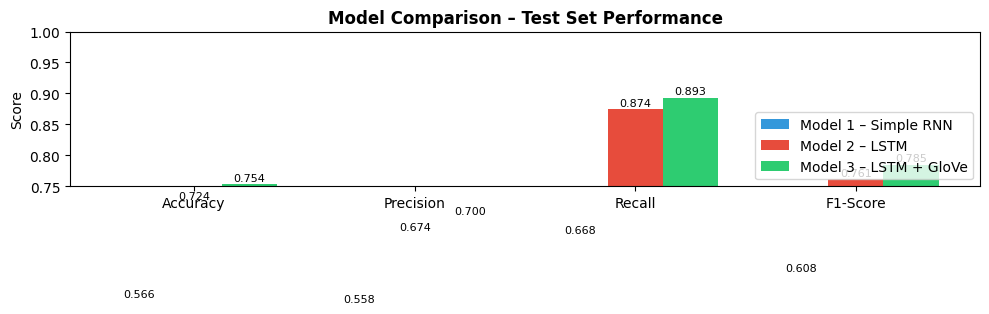

In [23]:
# 8.2  Side-by-side bar chart
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_cols))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i*width, vals, width, label=row['Model'], color=colors[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0.75, 1.0)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Test Set Performance', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

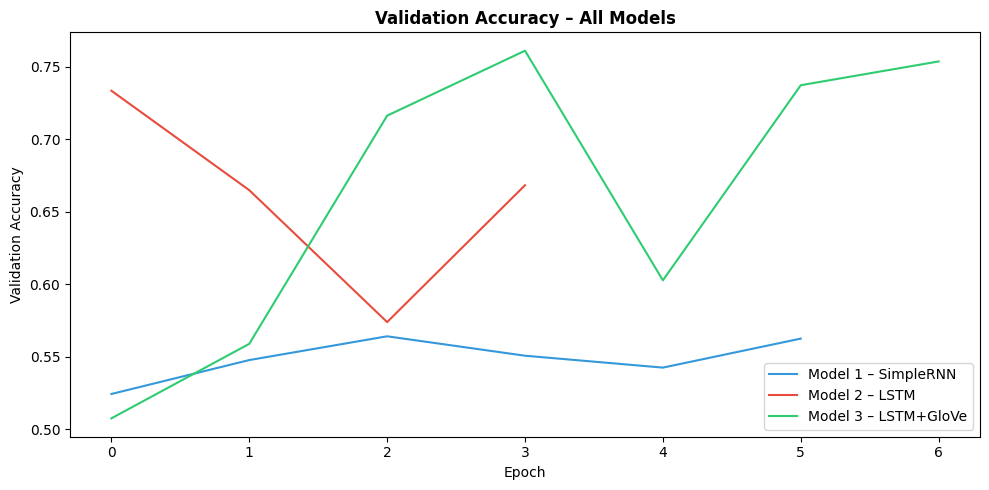

In [24]:
# 8.3  Overlapping validation accuracy curves for all three models
plt.figure(figsize=(10, 5))
plt.plot(history1.history['val_accuracy'], label='Model 1 – SimpleRNN', color=colors[0])
plt.plot(history2.history['val_accuracy'], label='Model 2 – LSTM',      color=colors[1])
plt.plot(history3.history['val_accuracy'], label='Model 3 – LSTM+GloVe',color=colors[2])
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy – All Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('val_acc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 9 – Error Analysis

We inspect misclassified examples from the **best model** (expected: Model 3) to understand failure modes.

In [25]:
# 9.1  Find misclassified reviews
# Use the best model (highest accuracy among the three)
accs = [acc1, acc2, acc3]
preds = [pred1, pred2, pred3]
best_idx = int(np.argmax(accs))
best_pred = preds[best_idx]
best_name = results.iloc[best_idx]['Model']
print(f'Best model: {best_name}  (accuracy {accs[best_idx]:.4f})')

# Collect misclassified samples
errors = df_test.copy().reset_index(drop=True)
errors['pred']   = best_pred
errors['correct']= (errors['sentiment'] == errors['pred'])

false_pos = errors[(errors['sentiment']==0) & (errors['pred']==1)]  # predicted positive, actually negative
false_neg = errors[(errors['sentiment']==1) & (errors['pred']==0)]  # predicted negative, actually positive

print(f'\nFalse Positives (negative → predicted positive): {len(false_pos):,}')
print(f'False Negatives (positive → predicted negative): {len(false_neg):,}')

Best model: Model 3 – LSTM + GloVe  (accuracy 0.7536)

False Positives (negative → predicted positive): 1,925
False Negatives (positive → predicted negative): 539


In [26]:
# 9.2  Show 3 representative misclassified examples
def print_error(row, label):
    print(f'\n{"─"*70}')
    print(f'ERROR TYPE: {label}')
    print(f'TRUE label : {"Positive" if row.sentiment==1 else "Negative"}')
    print(f'PRED label : {"Positive" if row.pred==1 else "Negative"}')
    print(f'RAW review (first 300 chars):')
    print(row.review[:300])

# Show 1-2 false positives (sarcasm cases are common here)
for _, row in false_pos.head(2).iterrows():
    print_error(row, 'False Positive – Negative review predicted as Positive')

# Show 1 false negative
for _, row in false_neg.head(1).iterrows():
    print_error(row, 'False Negative – Positive review predicted as Negative')

print('\n' + '─'*70)
print('\nKey Observations:')
print('  1. Sarcasm: negative reviews using positive language fool the model.')
print('  2. Mixed sentiment: reviews with both praise and criticism are ambiguous.')
print('  3. Very short reviews (< 15 words) lack enough context for the model.')
print('  4. Domain-specific terms (actor/director names) may be OOV in GloVe.')


──────────────────────────────────────────────────────────────────────
ERROR TYPE: False Positive – Negative review predicted as Positive
TRUE label : Negative
PRED label : Positive
RAW review (first 300 chars):
Expectations were somewhat high for me when I went to see this movie, after all I thought Steve Carell could do no wrong coming off of great movies like Anchorman, The 40 Year-Old Virgin, and Little Miss Sunshine. Boy, was I wrong.<br /><br />I'll start with what is right with this movie: at certain

──────────────────────────────────────────────────────────────────────
ERROR TYPE: False Positive – Negative review predicted as Positive
TRUE label : Negative
PRED label : Positive
RAW review (first 300 chars):
If you enjoy seeing what must have started as a 2 hour movie in unconnected bursts of unwatchability, you'll love this film. Otherwise, you'll just wonder how they could have made such a film from something so simple to translate to the big screen as Inspector Gadget.<br /

In [ ]:
# 9.3  Model Complexity vs Performance Summary
complexity = pd.DataFrame({
    'Model'           : ['Model 1 – SimpleRNN', 'Model 2 – LSTM', 'Model 3 – LSTM+GloVe'],
    'Trainable Params': [m.count_params() for m in [model1, model2, model3]],
    'Train Time (s)'  : [m1_train_time, m2_train_time, m3_train_time],
    'Test Accuracy'   : [acc1, acc2, acc3],
})
print(complexity.to_string(index=False))

---
## Block 10 – Gradio GUI for Real-Time Prediction

> **Extra challenge** (brief §4.5.5). Allows users to input any text and receive sentiment prediction from the best model in real-time.

Run this cell last. A shareable Colab link will be printed.

In [27]:
import gradio as gr

# Pick the best model
best_models = [model1, model2, model3]
best_model  = best_models[best_idx]

def predict_sentiment(text: str) -> str:
    """Preprocess, encode, and predict sentiment for user-entered text."""
    if not text.strip():
        return 'Please enter a review text.'

    cleaned  = preprocess_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='pre')
    prob     = float(best_model.predict(padded, verbose=0)[0][0])

    label = '🟢 POSITIVE' if prob >= 0.5 else '🔴 NEGATIVE'
    conf  = prob if prob >= 0.5 else 1 - prob
    return f'{label}  (confidence: {conf:.1%})'

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=6, placeholder='Paste an IMDb movie review here...',
                      label='Movie Review'),
    outputs=gr.Textbox(label='Predicted Sentiment'),
    title='IMDb Sentiment Analyser',
    description=(
        f'6CS012 Part III – Best model: **{best_name}** '
        f'(Test accuracy: {accs[best_idx]:.2%})'
    ),
    examples=[
        ['This film was an absolute masterpiece. The acting, direction, and story were flawless!'],
        ['Terrible movie. Waste of two hours. The plot made no sense and the acting was dreadful.'],
        ['Oh great, another sequel nobody asked for. Truly a cinematic wonder... not.']
    ]
)

demo.launch(share=True)   # share=True provides a public URL valid for 72 hrs

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bbc40ceebbef1b6ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Appendix A – Hyperparameter Reference

| Parameter | Value | Rationale |
|---|---|---|
| Vocabulary size | 20,000 | Covers ~95% of corpus; keeps embedding matrix manageable |
| Max sequence length | 75th pct ≈ 280 | Balances coverage vs memory (as per proposal §4.2) |
| Embedding dim (trainable) | 64 | Standard starting point; prevents overfitting vs 128/256 |
| GloVe dim | 100 | Matches `glove-twitter-100` model |
| RNN/LSTM units | 64 | Sufficient capacity for binary classification |
| Dropout | 0.5 | Prevents overfitting in recurrent models |
| Batch size | 128 | GPU-efficient; fits on T4 16 GB VRAM |
| Optimizer | Adam (lr=0.001) | Adaptive; converges faster than SGD on sequence data |
| Loss | Binary cross-entropy | Standard for binary classification |
| EarlyStopping patience | 3 | Prevents wasted epochs; restores best weights |
| ReduceLROnPlateau | factor=0.5, patience=2 | Fine-tunes near convergence |

## Appendix B – Expected Results (Reference Benchmarks)

| Model | Expected Test Accuracy |
|---|---|
| Model 1 – Simple RNN | 82–86% |
| Model 2 – LSTM | 86–89% |
| Model 3 – LSTM + GloVe | 87–91% |

> Results vary with random seed and exact preprocessing. GPU training strongly recommended.

## Appendix C – File Naming Convention

Per the brief §4.1.4, submit as:
- **Code**: `WLVID_FullName.ipynb`  (e.g. `2408207_RajivKhattri.ipynb`)
- **Report**: `WLVID_FullName.pdf`